In [1]:
import json
import re
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from wordcloud import WordCloud
from collections import Counter
from collections import defaultdict
import numpy as np
import nltk
from nltk.corpus import stopwords

In [10]:
from pathlib import Path

data_folder="videosPPmergedNoNPZ"
rows = []
json_files = glob(f"{data_folder}/*/description_videos_*.json")
print(len(json_files), "JSON files found.")
for json_path in json_files:
    video_id = Path(json_path).stem.replace("description_videos_", "")

    with open(json_path, "r") as f:
        data = json.load(f)

    for scene_key, content in data.items():
        scene_match = re.match(r".*/(\d+)", scene_key)
        if not scene_match:
            continue
        scene_id = scene_match.group(1)

        body_block = re.search(r"<BodyDesc>(.*?)</BodyDesc>", content, re.DOTALL)
        emo_block = re.search(r"<Emotions>(.*?)</Emotions>", content, re.DOTALL)

        if body_block:
            body_items = re.findall(
                r"<(\d+)>(.*?)</\1>", body_block.group(1), re.DOTALL
            )
            body_dict = {pid: desc.strip() for pid, desc in body_items}

            style_block = re.search(r"<Style>(.*?)</Style>", content, re.DOTALL)
            style_dict = {}
            if style_block:
                style_items = re.findall(
                    r"<(\d+)>(.*?)</\1>", style_block.group(1), re.DOTALL
                )
                style_dict = {pid: style.strip() for pid, style in style_items}

            for pid in set(body_dict) & set(style_dict):
                rows.append(
                    {
                        "video_id": video_id,
                        "scene_id": scene_id,
                        "person_id": pid,
                        "body_desc": body_dict[pid],
                        "style": style_dict[pid],
                    }
                )

df = pd.DataFrame(rows)
print(df.head(10))

3759 JSON files found.
      video_id scene_id person_id  \
0  video_11688        1         0   
1  video_12705       12         1   
2  video_12705       12         0   
3  video_12705       12         2   
4  video_12705        2         1   
5  video_12705        2         0   
6  video_12705        9         1   
7  video_12705        9         0   
8  video_12705        8         1   
9  video_12705        8         0   

                                           body_desc  \
0  Stationary, focused gaze on the reference imag...   
1  Kneeling, leaning into the embrace, arms wrapp...   
2  Walking forward, arms swinging slightly, focus...   
3  Standing upright, one hand on the other’s shou...   
4  Backing up, arms raised in defense, feet wide ...   
5     Bent at the knees, leaning forward in a lunge.   
6  Backpedaling, knees bent, maintaining guard st...   
7     Bent forward, legs wide, focused on attacking.   
8  One leg bent, other extended, torso upright, s...   
9  Low st

In [11]:
# Count body movements per scene and extract BodyDesc/SceneDesc texts
scene_movements = []
bodydesc_texts = []
scenedesc_texts = []

for json_path in json_files:
    match_vid = re.search(r"video_(\d+)", json_path)
    if not match_vid:
        continue
    video_id = match_vid.group(1)

    with open(json_path, "r") as f:
        data = json.load(f)

    for scene_key, content in data.items():
        scene_match = re.match(r"video_\d+/(\d+)", scene_key)
        if not scene_match:
            continue
        scene_id = scene_match.group(1)

        body_block = re.search(r"<BodyDesc>(.*?)</BodyDesc>", content, re.DOTALL)
        scene_desc = re.search(r"<SceneDesc>(.*?)</SceneDesc>", content, re.DOTALL)

        body_count = (
            len(re.findall(r"<\d+>.*?</\d+>", body_block.group(1), re.DOTALL))
            if body_block
            else 0
        )
        scene_movements.append(
            {"video_id": video_id, "scene_id": scene_id, "movement_count": body_count}
        )

        if body_block:
            bodydesc_texts.append(body_block.group(1))
        if scene_desc:
            scenedesc_texts.append(scene_desc.group(1))

df_movements = pd.DataFrame(scene_movements)
print(df_movements.head(10))

  video_id scene_id  movement_count
0    11688        2               0
1    11688        1               1
2    12705       12               3
3    12705        7               0
4    12705        2               2
5    12705        9               2
6    12705        8               2
7    12705       11               2
8    12705        3               2
9    12705        4               2


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/natsalaz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


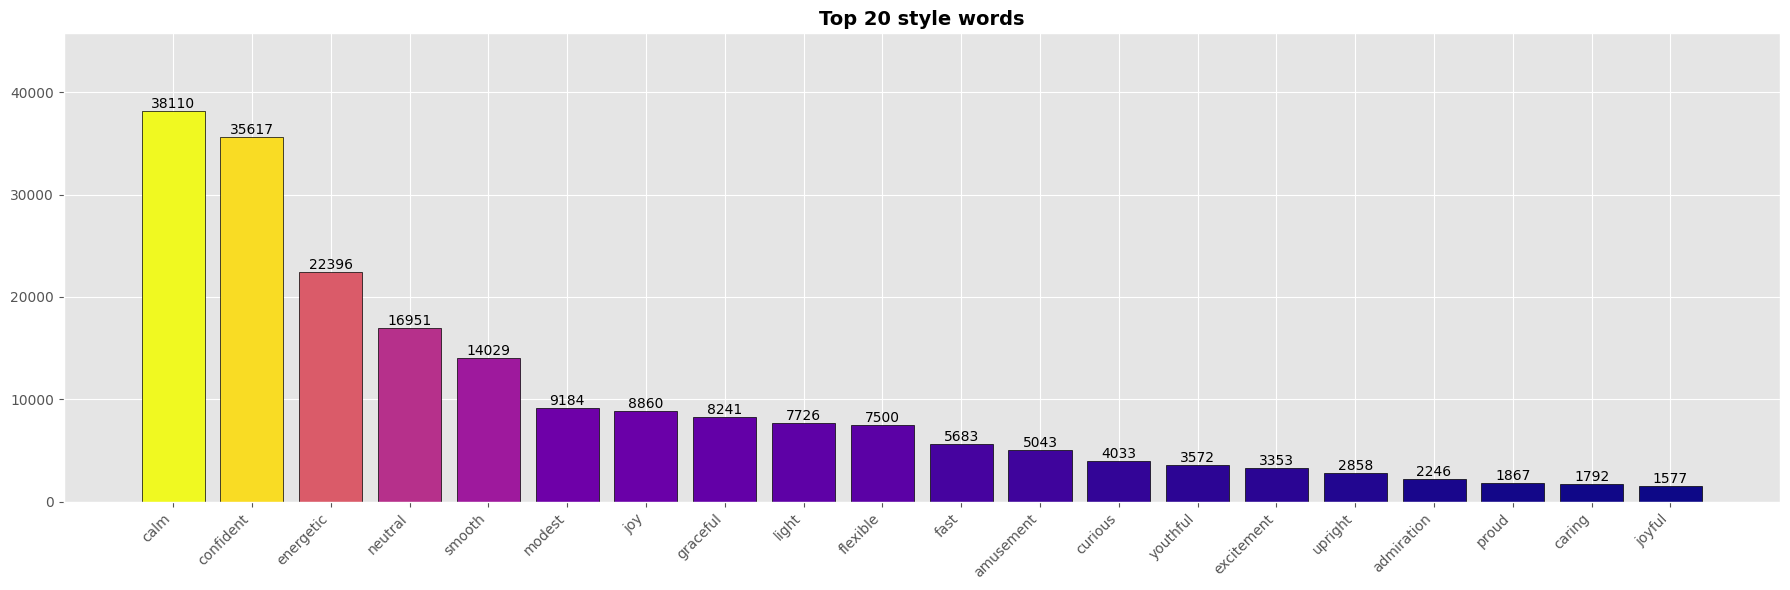

In [16]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))


def extract_words(text):
    return [
        w for w in re.findall(r"\b\w+\b", text.lower())
        if w not in stop_words and len(w) > 1
    ]

def extract_inner_bodydesc_texts(raw_list):
    texts = []
    for raw in raw_list:
        texts.extend([m.strip() for m in re.findall(r"<\d+>(.*?)</\d+>", raw, re.DOTALL)])
    return texts

if "df" in locals():
    fig, axes = plt.subplots(1, 1, figsize=(18, 6))
    plt.style.use("ggplot")

    def plot_pretty_bar(ax, labels, values, title, cmap_name="viridis"):
        cmap = plt.colormaps[cmap_name]
        norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
        colors = [cmap(norm(val)) for val in values]
        x = range(len(labels))
        bars = ax.bar(x, values, color=colors, edgecolor="black")
        ax.set_title(title, fontsize=14, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                str(height),
                ha="center",
                va="bottom",
                fontsize=10,
            )
        ax.set_ylim(0, max(values) * 1.2)

    if "style" in df.columns:
        style_words = []
        for style in df["style"]:
            style_words.extend(extract_words(style))
        style_counts = Counter(style_words).most_common(20)
        style_labels, style_vals = zip(*style_counts)
        plot_pretty_bar(
            axes, style_labels, style_vals, "Top 20 style words", cmap_name="plasma"
        )
    else:
        axes.axis("off")
        print("⚠️ Column `style` is missing in df.")

    plt.tight_layout()
    plt.show()
else:
    print("DataFrame `df` is not defined.")

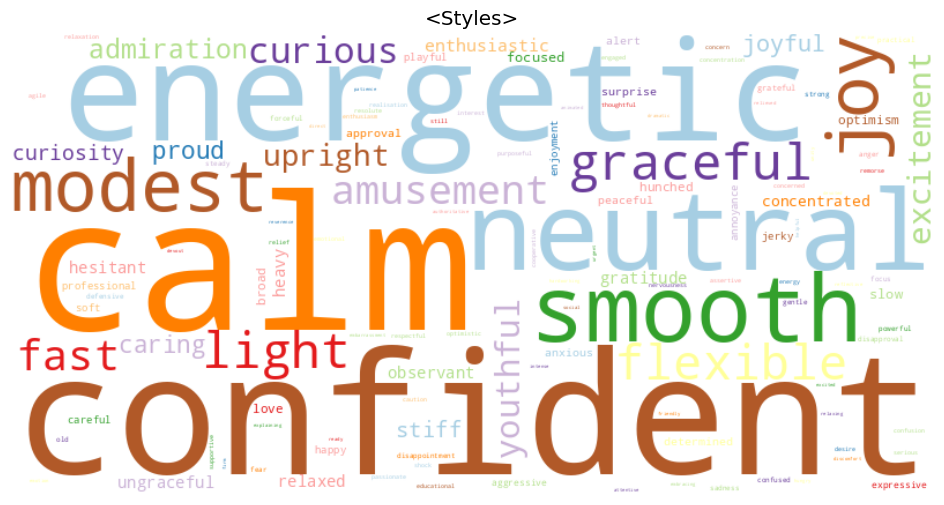

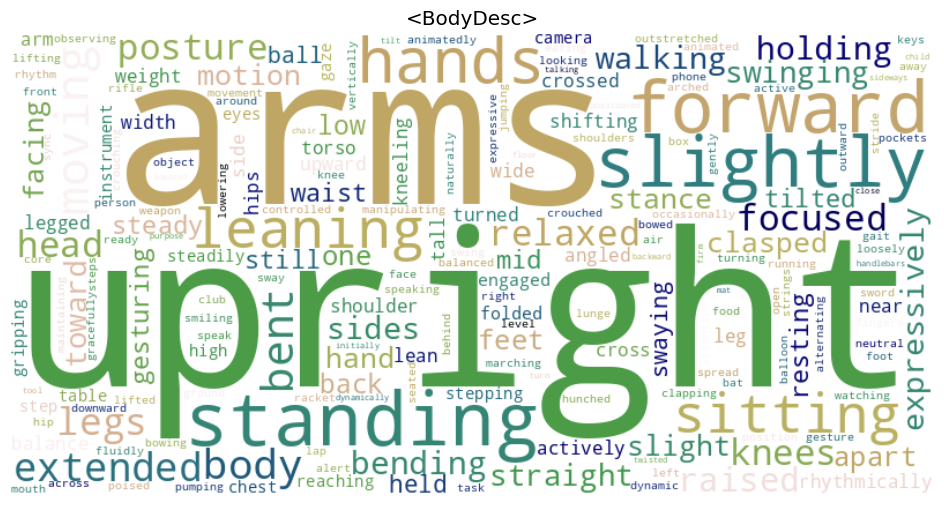

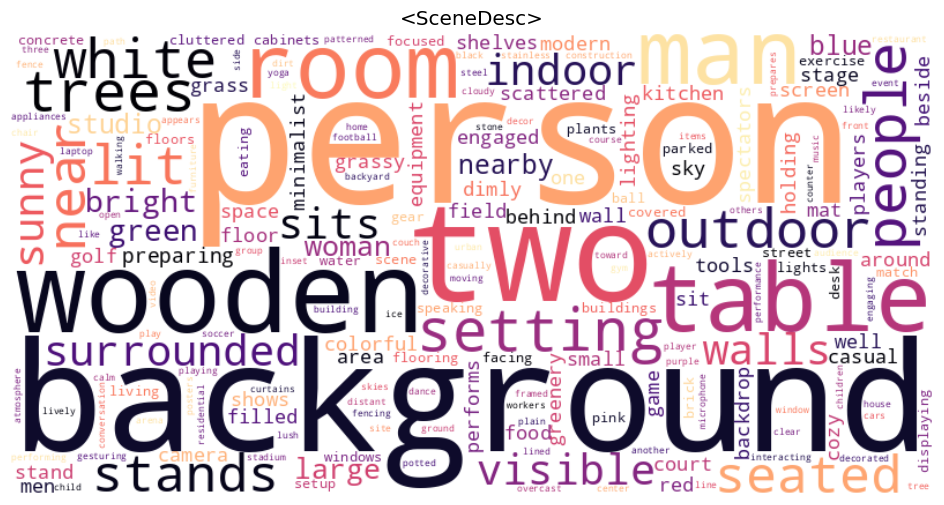

In [18]:
if "df" in locals() and "bodydesc_texts" in locals() and "scenedesc_texts" in locals():
    def show_wc(word_list, title, cmap):
        wc = WordCloud(width=800, height=400, background_color="white", colormap=cmap)
        wc.generate_from_frequencies(Counter(word_list))
        plt.figure(figsize=(14, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()

    style_words = [w for s in df["style"] for w in extract_words(s)] if "style" in df.columns else []
    if style_words:
        style_words = [w for s in df["style"] for w in extract_words(s)]
    body_words = [
        w
        for t in extract_inner_bodydesc_texts(bodydesc_texts)
        for w in extract_words(t)
    ]
    scene_words = [w for t in scenedesc_texts for w in extract_words(t)]

    show_wc(style_words, "<Styles>", "Paired")
    show_wc(body_words, "<BodyDesc>", "gist_earth")
    show_wc(scene_words, "<SceneDesc>", "magma")
else:
    print("Missing datafarme or description lists.")

--- Persons per scene ---
Total person sequences: 88515
Mean: 2.06
Median: 1.00
Q1: 1.00
Q3: 2.00

--- Scenes per video ---
Total scenes: 42968
Mean: 12.35
Median: 4.00
Q1: 2.00
Q3: 14.00


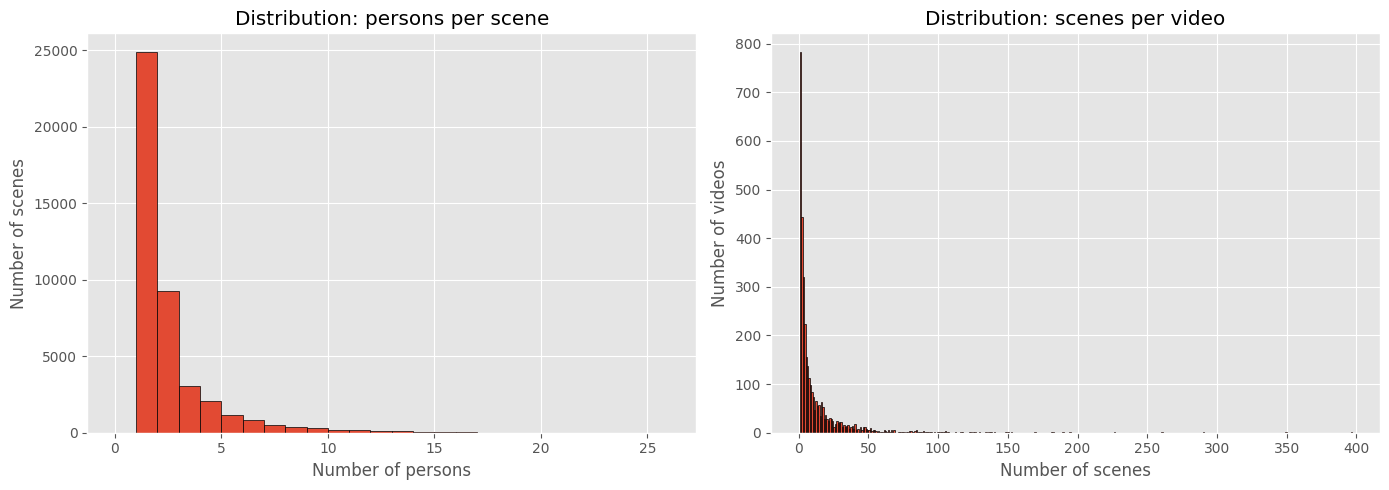

In [19]:
if "df" in locals():

    persons_per_scene = df.groupby(["video_id", "scene_id"])["person_id"].nunique()
    scenes_per_video = df.groupby("video_id")["scene_id"].nunique()

    print("--- Persons per scene ---")
    print(f"Total person sequences: {persons_per_scene.sum()}")
    print(f"Mean: {persons_per_scene.mean():.2f}")
    print(f"Median: {persons_per_scene.median():.2f}")
    print(f"Q1: {persons_per_scene.quantile(0.25):.2f}")
    print(f"Q3: {persons_per_scene.quantile(0.75):.2f}")

    print("\n--- Scenes per video ---")
    print(f"Total scenes: {scenes_per_video.sum()}")
    print(f"Mean: {scenes_per_video.mean():.2f}")
    print(f"Median: {scenes_per_video.median():.2f}")
    print(f"Q1: {scenes_per_video.quantile(0.25):.2f}")
    print(f"Q3: {scenes_per_video.quantile(0.75):.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        persons_per_scene, bins=range(0, persons_per_scene.max() + 2), edgecolor="black"
    )
    axes[0].set_title("Distribution: persons per scene")
    axes[0].set_xlabel("Number of persons")
    axes[0].set_ylabel("Number of scenes")

    axes[1].hist(
        scenes_per_video, bins=range(0, scenes_per_video.max() + 2), edgecolor="black"
    )
    axes[1].set_title("Distribution: scenes per video")
    axes[1].set_xlabel("Number of scenes")
    axes[1].set_ylabel("Number of videos")

    plt.tight_layout()
    plt.show()
else:
    print("DataFrame `df` is not defined.")

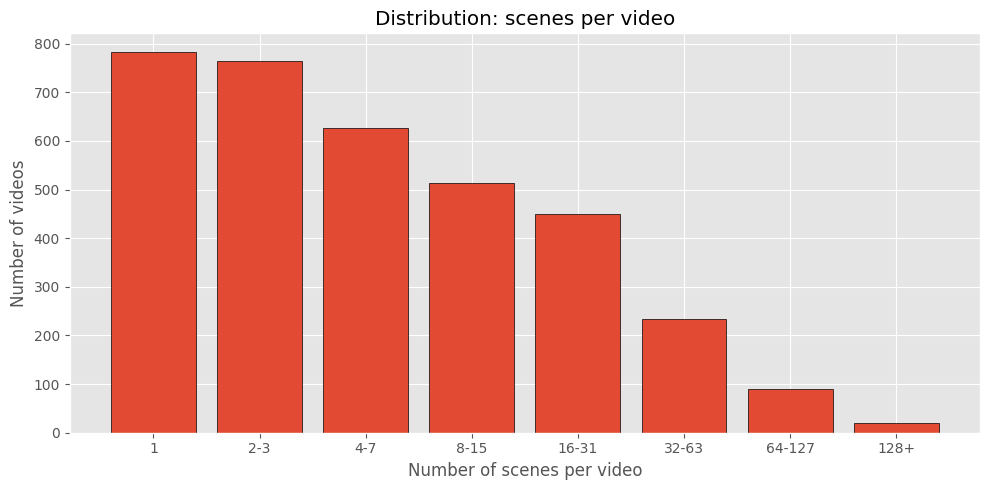

In [20]:
custom_bins = [0, 1, 3, 7, 15, 31, 63, 127, np.inf]
custom_labels = ["1", "2-3", "4-7", "8-15", "16-31", "32-63", "64-127", "128+"]

scenes_per_video_binned = pd.cut(
    scenes_per_video, bins=custom_bins, labels=custom_labels, right=True
)

scene_bin_counts = scenes_per_video_binned.value_counts(sort=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(scene_bin_counts.index.astype(str), scene_bin_counts.values, edgecolor="black")
ax.set_title("Distribution: scenes per video")
ax.set_xlabel("Number of scenes per video")
ax.set_ylabel("Number of videos")
plt.tight_layout()
plt.show()

In [ ]:
from glob import glob
import numpy as np
import os

poses_files = glob(f"{data_folder}/*/*.npz")
total_frames = 0
bad_files = []
person_count_per_file = {}

for path in poses_files:
    try:
        data = np.load(path, allow_pickle=True)
        person_keys = [key for key in data.files if key.startswith("body_")]
        num_persons = 0
        frames_in_file = 0

        for key in person_keys:
            body = data[key].item()
            if "poses" in body and hasattr(body["poses"], "shape"):
                n = body["poses"].shape[0]
                frames_in_file += n
                total_frames += n
                num_persons += 1

        person_count_per_file[os.path.basename(path)] = {
            "num_persons": num_persons,
            "total_frames": frames_in_file,
        }

    except Exception as e:
        bad_files.append((os.path.basename(path), str(e)))

# Résumé
print(f"\nFichiers traités : {len(person_count_per_file)}")
print(f"Total 3D pose frames: {total_frames:,}")

# Exemples
print("\nNombre de personnes + frames (exemples) :")
for fname, stats in list(person_count_per_file.items())[:10]:
    print(f"{fname}: {stats['num_persons']} personnes, {stats['total_frames']} frames")

if bad_files:
    print(f"\nFichiers invalides : {len(bad_files)}")
    for name, err in bad_files[:5]:
        print(f" - {name}: {err}")

In [22]:
total_persons = persons_per_scene.sum()
total_scenes = persons_per_scene.index.nunique()
total_videos = scenes_per_video.index.nunique()

print(
    f"{total_persons:,} sequences and person annotations across {total_scenes:,} scenes, taken from {total_videos:,} YouTube CC videos"
    f", covering {total_frames:,} 3D poses, "
    f"each annotated with structured descriptions of body movement, "
    f"emotion, style, and scene context."
)

88,515 sequences and person annotations across 42,968 scenes, taken from 3,479 YouTube CC videos, covering 0 3D poses, each annotated with structured descriptions of body movement, emotion, style, and scene context.


In [23]:
print(df)
df_ids = df.groupby(["video_id"])

          video_id scene_id person_id  \
0      video_11688        1         0   
1      video_12705       12         1   
2      video_12705       12         0   
3      video_12705       12         2   
4      video_12705        2         1   
...            ...      ...       ...   
88510  video_17734        9         0   
88511  video_17734        8         0   
88512  video_17734        5         0   
88513  video_17734        4         0   
88514  video_17734        3         0   

                                               body_desc  \
0      Stationary, focused gaze on the reference imag...   
1      Kneeling, leaning into the embrace, arms wrapp...   
2      Walking forward, arms swinging slightly, focus...   
3      Standing upright, one hand on the other’s shou...   
4      Backing up, arms raised in defense, feet wide ...   
...                                                  ...   
88510  Sitting upright, hands moving expressively as ...   
88511  Sitting upright, han

In [24]:
def has_large_gap(person_ids):
    person_ids = sorted(set(int(p) for p in person_ids))
    gaps = [b - a for a, b in zip(person_ids, person_ids[1:])]
    return any(gap > 2 for gap in gaps)

results = []
for (vid, sid), group in df.groupby(["video_id", "scene_id"]):
    pids = group["person_id"].tolist()
    if 0 not in pids and has_large_gap(pids):
        results.append(
            {"video_id": vid, "scene_id": sid, "person_ids": sorted(set(pids))}
        )

df_filtered = pd.DataFrame(results)
print(df_filtered)

#Donc ~1K mal indexées

       video_id scene_id                                       person_ids
0   video_11094        3                               [0, 1, 2, 5, 6, 7]
1   video_11534       78                         [0, 1, 2, 3, 6, 7, 8, 9]
2   video_11534       79                         [0, 1, 2, 3, 6, 7, 8, 9]
3   video_12142      131                                       [0, 11, 2]
4   video_12142      140                                       [0, 11, 2]
5   video_12142       53                                       [0, 11, 2]
6   video_12860       71                         [0, 1, 2, 3, 4, 7, 8, 9]
7   video_12860       87                         [0, 1, 2, 3, 4, 7, 8, 9]
8   video_13973      123                                        [0, 1, 4]
9   video_14322       24                                       [0, 11, 2]
10  video_15064        4  [0, 1, 11, 14, 15, 16, 17, 2, 3, 4, 5, 6, 7, 9]
11  video_15387       14                    [0, 10, 11, 3, 4, 5, 6, 7, 8]
12  video_17675        5              

In [25]:
df['emotion_main'] = df['emotion'].str.split(',').str[0].str.strip()

df['emotion_main'] = df['emotion_main'].str.split('–').str[0].str.strip()

emo_cpt = df["emotion_main"].value_counts().to_dict()

wordcloud = WordCloud(width=1000, height=500, background_color='white',
                      stopwords=stopwords).generate_from_frequencies(emo_cpt)

# Affichage
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud des émotions regroupées", fontsize=18)
plt.show()

KeyError: 'emotion'

{'Neutral': 91735, 'calm': 40904, 'focused': 11109, 'Happiness': 10258, 'Excitement': 6181, 'composed': 3896, 'attentive': 3766, 'concentrated': 2817, 'steady': 2724, 'smiling': 2565, 'relaxed': 2126, 'lively': 1529, 'casual': 1477, 'Sadness': 1339, 'engaged': 1192, 'Confidence': 1066, 'intense': 1037, 'focused on task': 962, 'alert': 916, 'determined': 911, 'active': 908, 'Happy': 873, 'expressive gestures': 858, 'dynamic': 786, 'Anger': 744, 'expressive': 667, 'animated gestures': 629, 'Surprise': 609, 'joyful': 602, 'calm demeanor': 578, 'confident': 574, 'Tired': 569, 'quick': 569, 'animated': 553, 'purposeful': 530, 'fast': 480, 'passive': 480, 'Energetic': 472, 'steady pace': 417, 'eager': 393, 'enthusiastic': 392, 'playful': 382, 'Confident': 376, 'Relaxed': 376, 'powerful': 376, 'balanced': 361, 'slow': 360, 'assertive': 352, 'relaxed posture': 347, 'curious': 347, 'observant': 340, 'cheerful': 328, 'steady gaze': 326, 'intense focus': 301, 'Decided': 292, 'strong': 291, 'firm'

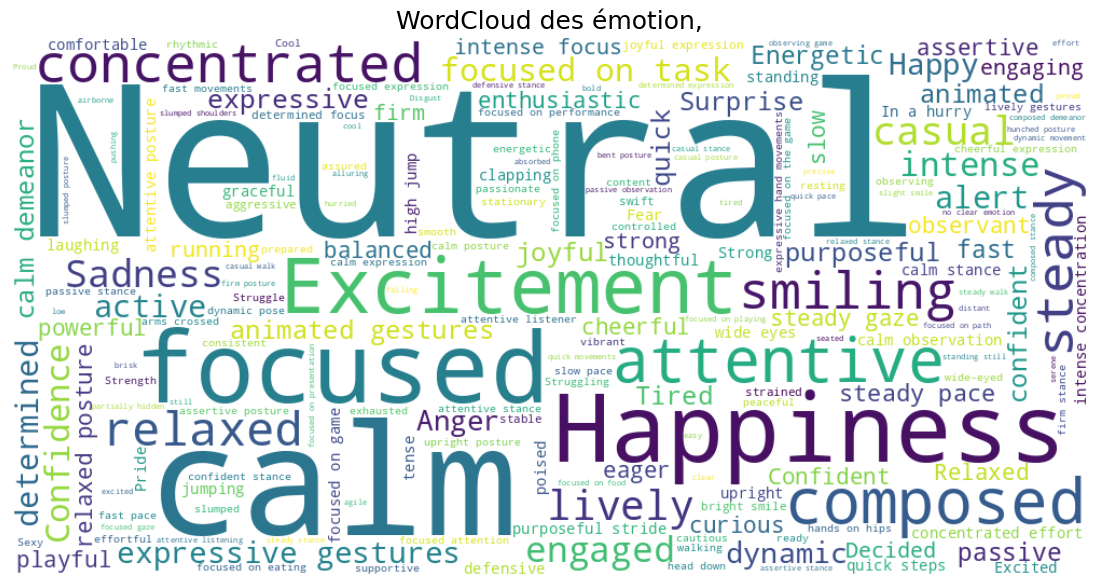

In [ ]:
# Séparer la partie avant la première virgule
emotion_segment = df["emotion"].str.split(",").str[0]

# Séparer tout ce qu’il y a autour des tirets
emotion_parts = emotion_segment.str.split("–")

# Nettoyage des morceaux
df["emotions"] = emotion_parts.apply(lambda parts: [p.strip() for p in parts])

# Explosion pour avoir une émotion par ligne
df_exploded = df.explode("emotions")

# Compter les fréquences
emo_counts = df_exploded["emotions"].value_counts().to_dict()
print(emo_counts)
# Générer le WordCloud
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

stopwords = set(STOPWORDS)
wordcloud = WordCloud(
    width=1000, height=500, background_color="white", stopwords=stopwords
).generate_from_frequencies(emo_counts)

# Affichage
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "WordCloud des émotion,", fontsize=18
)
plt.show()

In [ ]:
# Extraire la partie principale de l'émotion
df["emotion_main"] = (
    df["emotion"].str.split(",").str[0].str.split("–").str[0].str.strip()
)

# Liste unique des émotions et styles
emotions = set(df["emotion_main"].dropna().str.lower().unique())
styles = set(df["style"].dropna().str.lower().unique())

# Intersection des deux
common = emotions.intersection(styles)

In [ ]:
# Normaliser les champs pour comparaison (minuscule + strip)
df["emotion_main_norm"] = (
    df["emotion"].str.split(",").str[0].str.split("–").str[0].str.strip().str.lower()
)
df["style_norm"] = df["style"].str.strip().str.lower()

# Comparer chaque ligne pour voir si le même mot apparaît dans les deux colonnes
df["match"] = df["emotion_main_norm"] == df["style_norm"]

# Compter le nombre total de correspondances exactes par ligne
match_count = df["match"].sum()

# Renvoyer le nombre total
match_count

31142

In [ ]:
# Filtrer les lignes où le mot principal de 'emotion' est identique à 'style'
matching_rows = df[df["emotion_main_norm"] == df["style_norm"]]

# Compter les occurrences par mot
matching_counts = matching_rows["emotion_main_norm"].value_counts().reset_index()
matching_counts.columns = ["word", "count"]

# Affichage direct
print(matching_counts)

            word  count
0        neutral  28145
1          tired    556
2      energetic    399
3        relaxed    374
4      confident    351
..           ...    ...
59         march      1
60      balanced      1
61      prepared      1
62  concentrated      1
63     adjusting      1

[64 rows x 2 columns]


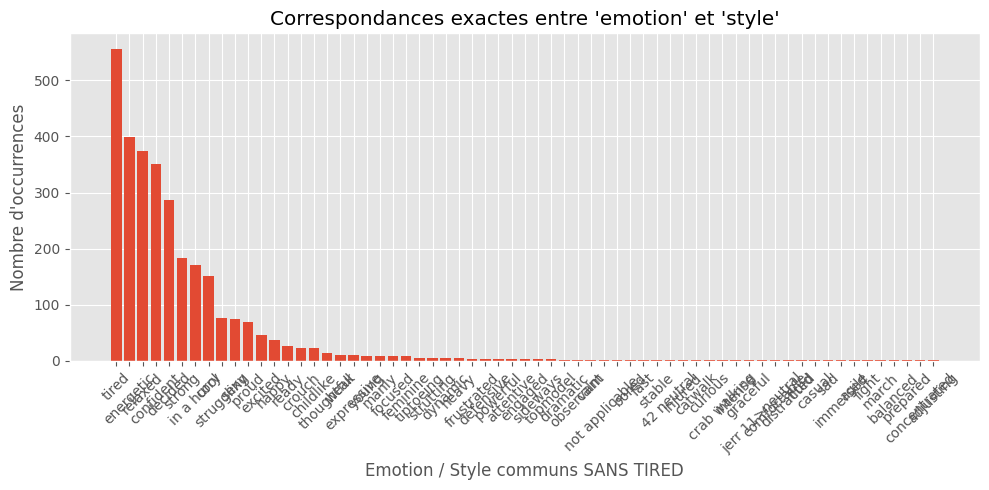

In [ ]:
# Reprendre les données de matching_counts précédemment calculées
matching_rows = df[df["emotion_main_norm"] == df["style_norm"]]
matching_counts = matching_rows["emotion_main_norm"].value_counts().reset_index()
matching_counts.columns = ["word", "count"]
matching_counts = matching_counts.iloc[1:]
# Tracer un barplot
plt.figure(figsize=(10, 5))
plt.bar(matching_counts["word"], matching_counts["count"])
plt.xlabel("Emotion / Style communs SANS TIRED")
plt.ylabel("Nombre d'occurrences")
plt.title("Correspondances exactes entre 'emotion' et 'style'")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
opposites_emotions = {
    "afraid": ["confident", "calm", "composed"],
    "angry": ["relaxed", "peaceful", "smiling"],
    "catwalk": ["awkward", "neutral", "passive"],
    "childlike": ["serious", "composed", "focused"],
    "confident": ["shy", "nervous", "insecure"],
    "cool": ["tense", "agitated", "expressive"],
    "crab walking": ["graceful", "purposeful", "upright"],
    "crouch": ["upright", "assertive", "proud"],
    "decided": ["indecisive", "confused", "hesitant"],
    "depressed": ["joyful", "engaged", "cheerful"],
    "drunk": ["balanced", "aware", "focused"],
    "energetic": ["tired", "calm", "still"],
    "excited": ["calm", "neutral", "casual"],
    "fearful": ["brave", "relaxed", "steady"],
    "feminine": ["strong", "confident", "assertive"],
    "flap": ["composed", "focused", "steady"],
    "frustrated": ["satisfied", "serene", "peaceful"],
    "goose-step": ["relaxed", "natural", "casual"],
    "happy": ["sad", "passive", "gloomy"],
    "heavy": ["light", "playful", "carefree"],
    "in a hurry": ["calm", "patient", "relaxed"],
    "injured": ["strong", "energized", "comfortable"],
    "inverse": ["natural", "fluid", "normal"],
    "lame walking": ["confident", "strong", "engaged"],
    "limp": ["upright", "determined", "steady"],
    "manly": ["gentle", "soft", "sensitive"],
    "march": ["soft", "calm", "casual"],
    "masculine": ["emotional", "warm", "nurturing"],
    "mummy": ["joyful", "lively", "engaged"],
    "neutral": ["emotional", "excited", "intense"],
    "old": ["youthful", "lively", "energetic"],
    "proud": ["ashamed", "insecure", "humbled"],
    "relaxed": ["tense", "nervous", "alert"],
    "sad": ["happy", "smiling", "cheerful"],
    "sexy": ["plain", "shy", "inexpressive"],
    "sideways": ["direct", "confident", "focused"],
    "sneak": ["open", "bold", "assertive"],
    "strong": ["weak", "tired", "unsure"],
    "struggling": ["composed", "focused", "confident"],
    "strutting": ["shy", "awkward", "humble"],
    "tiptoeing": ["bold", "confident", "grounded"],
    "tired": ["energized", "motivated", "alert"],
    "topmodel": ["awkward", "slouched", "tired"],
    "weak": ["strong", "confident", "balanced"],
    "young": ["mature", "serious", "calm"],
    "zombie": ["lively", "present", "expressive"],
}


df['emotion_main_norm'] = df['emotion'].str.split(',').str[0].str.split('–').str[0].str.strip().str.lower()
df['style_norm'] = df['style'].str.strip().str.lower()
def is_opposite(row):
    emo = row['emotion_main_norm']
    sty = row['style_norm']
    return sty in opposites_emotions.get(emo, [])

df['opposite'] = df.apply(is_opposite, axis=1)
opposite_matches = df[df['opposite'] == True]
opposite_summary = opposite_matches.groupby(['emotion_main_norm', 'style_norm']).size().reset_index(name='count')

print(opposite_summary)

  emotion_main_norm style_norm  count
0           neutral    excited     50
1           neutral    intense     11


## Donc ici a priori, les styles et émotions ne se contredisent pas trop.

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from collections import Counter


def get_main_emotion(emotion_array):
    if isinstance(emotion_array, np.ndarray):
        # Convertir en liste, filtrer "unknown"
        filtered = [e for e in emotion_array.tolist() if e != "unknown"]
        if not filtered:
            return None
        # Compter les occurrences
        most_common = Counter(filtered).most_common(1)
        return most_common[0][0]  # retourne l'émotion la plus fréquente
    return None


# Récupération des chemins des fichiers npz
npz_files = glob.glob(os.path.join("../../video_*", "video_*_merged_scene_*.npz"))

# Stockage des résultats
records = []

for npz_path in npz_files:
    filename = os.path.basename(npz_path)
    foldername = os.path.basename(os.path.dirname(npz_path))

    try:
        video_id = foldername.split("_")[1]  # ex: '622'
        scene_id = filename.split("_scene_")[1].split(".npz")[0]  # ex: '1'

        data = np.load(npz_path, allow_pickle=True)

        for body_key in data.files:
            body_data = data[body_key].item()

            if "emotions" in body_data:
                emotion_array = body_data["emotions"]
                main_emotion = get_main_emotion(emotion_array)

                records.append({
                    "video_id": video_id,
                    "scene_id": scene_id,
                    "person_id": body_key.replace("body_", ""),
                    "emotions": main_emotion,
                    "npz_path": npz_path
                })
    except Exception as e:
        print(f"Erreur pour {npz_path} : {e}")

df_emotions = pd.DataFrame(records)
print(df_emotions.head())

  video_id scene_id person_id emotions  \
0     3210        2         0     None   
1     3210        3         0     None   
2     3210        1         0      sad   
3     1455        3         0      sad   
4     1455        2         0     None   

                                         npz_path  
0  ../../video_3210/video_3210_merged_scene_2.npz  
1  ../../video_3210/video_3210_merged_scene_3.npz  
2  ../../video_3210/video_3210_merged_scene_1.npz  
3  ../../video_1455/video_1455_merged_scene_3.npz  
4  ../../video_1455/video_1455_merged_scene_2.npz  


In [ ]:
style_to_emotion_opposites = {
    "afraid": ["happy", "confident", "neutral"],  # peur ↔ joie, confiance, calme
    "angry": ["happy", "neutral", "surprise"],  # colère ↔ joie, calme, étonnement
    "catwalk": [
        "fear",
        "disgust",
        "sad",
    ],  # démarche confiante ↔ insécurité, malaise, repli
    "childlike": ["neutral", "sad", "disgust"],  # enfantin ↔ sérieux, distant, cynique
    "confident": ["fear", "sad", "disgust"],  # assurance ↔ peur, tristesse, rejet
    "cool": ["angry", "surprise", "sad"],  # détendu ↔ tension, agitation, imprévu
    "crab walking": ["confident", "happy", "neutral"],  # étrange ↔ contrôle, aisance
    "crouch": ["confident", "happy", "neutral"],  # repli ↔ ouverture
    "decided": ["fear", "sad", "disgust"],  # détermination ↔ doute
    "depressed": ["happy", "surprise", "neutral"],  # ↔ joie, émerveillement
    "drunk": ["neutral", "angry", "disgust"],  # ↔ maîtrise, lucidité, sérieux
    "energetic": ["sad", "neutral", "disgust"],  # hyperactivité ↔ vide, calme, rejet
    "excited": ["neutral", "sad", "disgust"],  # excitation ↔ modération
    "fearful": ["happy", "confident", "neutral"],  # peur ↔ calme
    "feminine": ["angry", "disgust", "fear"],  # douceur ↔ agressivité, rejet
    "flap": ["neutral", "confident", "happy"],  # agitation ↔ calme
    "frustrated": ["happy", "neutral", "surprise"],  # frustration ↔ acceptation, calme
    "goose-step": ["sad", "neutral", "happy"],  # exagéré ↔ naturel
    "happy": ["happy", "fear", "angry"],  # ↔ tristesse, peur, colère
    "heavy": ["happy", "neutral", "surprise"],  # ↔ légèreté, joie
    "in a hurry": ["neutral", "happy", "sad"],  # ↔ détente
    "injured": ["happy", "neutral", "surprise"],  # ↔ vitalité
    "inverse": ["neutral", "happy", "sad"],  # ↔ naturel
    "lame walking": ["happy", "confident", "neutral"],  # ↔ confiance
    "limp": ["confident", "happy", "neutral"],
    "manly": ["sad", "fear", "disgust"],  # ↔ vulnérabilité
    "march": ["neutral", "surprise", "happy"],  # ↔ rigidité
    "masculine": ["sad", "fear", "disgust"],
    "mummy": ["surprise", "happy", "neutral"],  # ↔ présence
    "neutral": ["fear", "disgust", "surprise"],  # ↔ émotion forte
    "old": ["happy", "surprise", "neutral"],  # ↔ jeunesse
    "proud": ["sad", "fear", "disgust"],  # ↔ honte
    "relaxed": ["angry", "fear", "surprise"],  # ↔ tension
    "sad": ["happy", "surprise", "neutral"],
    "sexy": ["disgust", "sad", "fear"],
    "sideways": ["confident", "happy", "surprise"],
    "sneak": ["confident", "happy", "surprise"],
    "strong": ["sad", "fear", "disgust"],
    "struggling": ["happy", "neutral", "confident"],
    "strutting": ["fear", "sad", "neutral"],
    "tiptoeing": ["confident", "angry", "surprise"],
    "tired": ["happy", "surprise", "neutral"],
    "topmodel": ["sad", "fear", "disgust"],
    "weak": ["happy", "confident", "surprise"],
    "young": ["sad", "fear", "disgust"],
    "zombie": ["happy", "surprise", "neutral"],
}

#NOT USED YET

In [ ]:
if df["video_id"].dtype == object:
    df["video_id"] = df["video_id"].str.replace("video_", "").astype(int)

for col in ["video_id", "scene_id", "person_id"]:
    df_emotions[col] = df_emotions[col].astype(int)
    df[col] = df[col].astype(int)

# merging of the 2 dataframes, reminder: df is from the JSON parsing and df_emotions from the npz files
merged = pd.merge(
    df_emotions, df, on=["video_id", "scene_id", "person_id"], suffixes=("_df1", "_df2")
)

def compare_emotions(row):
    emo1 = row["emotions_df1"]
    emo2 = row["emotions_df2"]

    if not isinstance(emo1, str) or emo1.strip() == "":
        return pd.NA
    if isinstance(emo2, list):
        emo2_clean = [e.lower() for e in emo2 if isinstance(e, str)]
        return emo1.lower() in emo2_clean if emo2_clean else pd.NA
    if isinstance(emo2, str):
        return emo1.lower() == emo2.lower()

    return pd.NA

merged["same_emotion"] = merged.apply(compare_emotions, axis=1)

# Stats
num_total = len(merged)
num_known = merged["same_emotion"].notna().sum()
num_yes = merged["same_emotion"].sum(skipna=True)
num_no = (merged["same_emotion"] == False).sum()
num_na = merged["same_emotion"].isna().sum()

print("Total merged lines :", num_total)
print("Identical emotions :", num_yes)
print("Different emotions :", num_no)
print("Missing (None in npzs so not enough faces detected in the npz file) :", num_na)

# 
print("\nExemple of disagreements :")
print(
    merged[merged["same_emotion"] == False][
        ["video_id", "scene_id", "person_id", "emotions_df1", "emotions_df2"]
    ].head(10)
)

Total merged lines : 106440
Identical emotions : 10541
Different emotions : 50034
Missing (None in npzs so not enough faces detected in the npz file) : 45865

Exemple of disagreements :
    video_id  scene_id  person_id emotions_df1              emotions_df2
2       3210         1          0          sad           [Neutral, calm]
3       1455         3          0          sad           [Neutral, calm]
6        849         2          0        happy  [Sadness, head in hands]
8        849         1          0        happy           [Neutral, calm]
13      2714         2          0          sad   [Neutral, concentrated]
16      2714         5          0        anger   [Neutral, concentrated]
17      2714         5          1          sad           [Neutral, calm]
18      3298         3          0          sad           [Neutral, calm]
19      3298         3          1        anger   [Neutral, concentrated]
25      3298         9          1          sad        [Sadness, subdued]


In [ ]:
keyword_to_emotion = {
    "calm": "neutral",
    "focused": "neutral",
    "relaxed": "neutral",
    "neutral": "neutral",
    "focused": "neutral",
    "attentive": "neutral",
    "composed": "neutral",
    "relaxed": "neutral",
    "confident": "neutral",
    "confidence": "neutral",
    "casual": "neutral",
    "concentrated": "neutral",
    "comfortable": "neutral",
    "content": "neutral",
    "smile": "happy",
    "joy": "happy",
    "joyful": "happy",
    "happy": "happy",
    "excited": "happy",
    "happiness": "happy",
    "excitement": "happy",
    "joyful": "happy",
    "cheerful": "happy",
    "smiling": "happy",
    "smile": "happy",
    "animated": "happy",
    "lively": "happy",
    "enthusiastic": "happy",
    "engaged": "happy",
    "sad": "sad",
    "sadness": "sad",
    "cry": "sad",
    "crying": "sad",
    "down": "sad",
    "tired": "sad",
    "down": "sad",
    "angry": "angry",
    "anger": "angry",
    "mad": "angry",
    "frustrated": "angry",
    "aggressive": "angry",
    "fear": "fear",
    "scared": "fear",
    "afraid": "fear",
    "nervous": "fear",
    "anxious": "fear",
    "cautious": "fear",
    "nervous": "fear",
    "tense": "fear",
    "disgust": "disgust",
    "disgusted": "disgust",
    "surprise": "surprise",
    "surprised": "surprise",
    "shocked": "surprise",
}

In [ ]:
import re
def extract_emotion_keywords_v2(emotion_list):
    if not isinstance(emotion_list, list):
        return []

    keywords = []
    for e in emotion_list:
        if not isinstance(e, str):
            continue
        words = re.findall(r"\b[a-zA-Z]+\b", e.lower())
        for word in words:
            if word in keyword_to_emotion:
                keywords.append(keyword_to_emotion[word])
    return list(set(keywords))  # enlever doublons

In [ ]:
def is_same_emotion_v2(row):
    emo1 = row["emotions_df1"]
    emo2 = row["emotions_df2"]

    if not isinstance(emo1, str) or not isinstance(emo2, list):
        return pd.NA

    emo1 = emo1.lower()
    emo2_mapped = extract_emotion_keywords_v2(emo2)

    return emo1 in emo2_mapped

In [ ]:
merged["same_emotion"] = merged.apply(is_same_emotion_v2, axis=1)

num_total = len(merged)
num_valid = merged["same_emotion"].notna().sum()
num_identical = merged["same_emotion"].sum(skipna=True)
num_different = (merged["same_emotion"] == False).sum()
num_missing = merged["same_emotion"].isna().sum()

print("Total merged lines :", num_total)
print("Identical emotions :", num_identical)
print("Different emotions :", num_different)
print(
    "Missing (None in npzs so not enough faces detected in the npz file) :", num_missing
)
print("With a little mapping we get more identical emotions than before, but still not even close to perfect.")

Total merged lines : 106440
Identical emotions : 14474
Different emotions : 46101
Missing (None in npzs so not enough faces detected in the npz file) : 45865
With a little mapping we get more identical emotions than before, but still not even close to perfect.


In [ ]:
merged["emotion_df2_mapped"] = merged["emotions_df2"].apply(extract_emotion_keywords_v2)

X = 5  # nombre de lignes à afficher

print(
    merged[
        [
            "video_id",
            "scene_id",
            "person_id",
            "emotions_df1",  # étiquette unique (df_emotions)
            "emotions_df2",  # liste originale (df)
            "emotion_df2_mapped",  # émotions interprétées
            "same_emotion",  # match ou pas
        ]
    ].head(X)
)

   video_id  scene_id  person_id emotions_df1                emotions_df2  \
0      3210         2          0         None  [Neutral, focused on task]   
1      3210         3          0         None  [Neutral, quick departure]   
2      3210         1          0          sad             [Neutral, calm]   
3      1455         3          0          sad             [Neutral, calm]   
4      1455         1          0         None             [Neutral, calm]   

  emotion_df2_mapped same_emotion  
0          [neutral]         <NA>  
1          [neutral]         <NA>  
2          [neutral]        False  
3          [neutral]        False  
4          [neutral]         <NA>  


In [ ]:
emotion_opposites = {
    "happy": ["sad", "angry"],
    "sad": ["happy", "surprise"],
    "angry": ["happy", "neutral"],
    "fear": ["neutral", "happy"],  # "confident" is mapped to "neutral" par extension
    "disgust": ["happy", "surprise"],
    "surprise": ["sad", "neutral"],
    "neutral": ["angry", "surprise"],
}
def is_opposite_emotion_to_df2(row):
    emo1 = row['emotions_df1']
    emo2 = row['emotion_df2_mapped']

    if not isinstance(emo1, str) or not isinstance(emo2, list):
        return pd.NA

    emo1 = emo1.lower()
    emo2 = [e.lower() for e in emo2]

    if emo1 not in emotion_opposites:
        return pd.NA
    return any(e in emotion_opposites[emo1] for e in emo2)


In [ ]:
merged["emotion_opposite_detected"] = merged.apply(is_opposite_emotion_to_df2, axis=1)

num_total = len(merged)
num_known = merged["emotion_opposite_detected"].notna().sum()
num_yes = merged["emotion_opposite_detected"].sum(skipna=True)
num_no = (merged["emotion_opposite_detected"] == False).sum()
num_na = merged["emotion_opposite_detected"].isna().sum()
pct_yes = round(100 * num_yes / num_known, 2) if num_known > 0 else 0
pct_no = round(100 * num_no / num_known, 2) if num_known > 0 else 0
pct_na = round(100 * num_na / num_total, 2)

print("\nOpposite emotions :")
print(f"Opposite : {num_yes}/{num_known} ({pct_yes}%)")
print(f"Not opposite : {num_no}/{num_known} ({pct_no}%)")
print(f"Unknown (NaN) : {num_na}/{num_total} ({pct_na}%)")


Opposite emotions :
Opposite : 4654/46058 (10.1%)
Not opposite : 41404/46058 (89.9%)
Unknown (NaN) : 60382/106440 (56.73%)


In [ ]:
X = 50
print(
    merged[
        [
            "video_id",
            "scene_id",
            "person_id",
            "emotions_df1", 
            "emotions_df2", 
            "emotion_df2_mapped", 
            "emotion_opposite_detected", 
        ]
    ].head(X)
)

    video_id  scene_id  person_id emotions_df1                emotions_df2  \
0       3210         2          0         None  [Neutral, focused on task]   
1       3210         3          0         None  [Neutral, quick departure]   
2       3210         1          0          sad             [Neutral, calm]   
3       1455         3          0          sad             [Neutral, calm]   
4       1455         1          0         None             [Neutral, calm]   
5        849         3          1         None             [Neutral, calm]   
6        849         2          0        happy    [Sadness, head in hands]   
7        849         5          1         None            [Fear, cautious]   
8        849         1          0        happy             [Neutral, calm]   
9        849         7          1         None             [Neutral, calm]   
10       849         6          1         None           [Neutral, casual]   
11       849         4          1         None  [Neutral, focuse